In [77]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [78]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.metrics import mean_squared_error
color_pal = sns.color_palette()

In [79]:
def print_metrics(y_test, y_pred,y_label, alg_name, dataset_name):

    # Calculate RMSE
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    print(f'RMSE Score on Test set: {rmse:.2f}')

    # Mean Absolute Error (MAE)
    mae = np.mean(np.abs(y_test - y_pred.reshape(y_pred.shape[0])))
    print(f'mae Score on Test set: {mae:.2f}')

    # R-squared (R2) Score
    mean_actual = np.mean(y_test)
    total_sum_of_squares = np.sum((y_test - mean_actual) ** 2)
    residual_sum_of_squares = np.sum((y_test - y_pred.reshape(y_pred.shape[0])) ** 2)
    r2 = 1 - (residual_sum_of_squares / total_sum_of_squares)
    print(f'r2 Score on Test set: {r2:.2f}')

    # Mean Bias Deviation (MBE):
    mbe = np.mean(y_test - y_pred.reshape(y_pred.shape[0]))
    print(f'mbe Score on Test set: {mbe:.2f}')

    # Median Absolute Error (MedAE):
    medae = np.median(np.abs(y_test - y_pred.reshape(y_pred.shape[0])))
    print(f'medae Score on Test set: {medae:.2f}')

    # Coefficient of Determination (COD):
    mean_actual = np.mean(y_test)
    total_sum_of_squares = np.sum((y_test - mean_actual) ** 2)
    residual_sum_of_squares = np.sum((y_test - y_pred.reshape(y_pred.shape[0])) ** 2)
    cod = 1 - (residual_sum_of_squares / total_sum_of_squares)
    print(f'cod Score on Test set: {cod:.2f}')

    # Explained Variance Score:
    explained_variance = 1 - (np.var(y_test - y_pred.reshape(y_pred.shape[0])) / np.var(y_test))
    print(f'explained_variance Score on Test set: {explained_variance:.2f}')

    # Relative Absolute Error (RAE):
    mae = np.mean(np.abs(y_test - y_pred.reshape(y_pred.shape[0])))
    baseline_mae = np.mean(np.abs(y_test - np.mean(y_test)))
    rae = mae / baseline_mae
    print(f'rae Score on Test set: {rae:.2f}')

    with open(f'./metrics-{alg_name}-{dataset_name}.txt','w') as f:
        txt = f"rmse: {rmse}"+'\n'+ f"mae: {mae}"+'\n'+f"r2: {r2}"+'\n'+f"medae: {medae}"+'\n'+f"cod: {cod}"+'\n'+f"explained_variance: {explained_variance}"+'\n'+f"rae: {rae}"+'\n'
        f.write(txt)


In [80]:
def plot_act_vs_pred(y_test, y_pred,y_label, alg_name, dataset_name):
    print_metrics(y_test, y_pred,y_label, alg_name, dataset_name)
    # Plot predictions vs. actual values
    plt.figure(figsize=(8, 3),)
    plt.plot(test.index, y_test, label='Actual', color='blue')
    plt.plot(test.index, y_pred, label='Predicted', color='red')
    plt.title(f'Actual vs. Predicted - {alg_name} - {dataset_name}')
    plt.xlabel('Date')
    plt.ylabel(y_label)
    plt.legend()
    plt.savefig(f"Actual vs. Predicted - {alg_name}' - {dataset_name}.png")
    plt.savefig(f"Actual vs. Predicted - {alg_name}' - {dataset_name}.svg", format='svg', dpi=1200, bbox_inches='tight', facecolor='white')
    plt.show()

In [81]:

dataset_name = 'pf_filled'
df = pd.read_csv(f'/content/drive/MyDrive/datasets (1)/time-series-forecasting/{dataset_name}.csv')
df = df.set_index('Time')
selected_column = df.columns[0]
df = df[selected_column]
df.index = pd.to_datetime(df.index)

In [82]:
df = df.to_frame()

In [83]:
df

,prod_k28
Time,
2020-12-22 00:00:00,0.0
2020-12-22 01:00:00,0.0
2020-12-22 02:00:00,0.0
2020-12-22 03:00:00,0.0
2020-12-22 04:00:00,0.0
...,...
2023-01-10 16:00:00,0.3
2023-01-10 17:00:00,0.0
2023-01-10 18:00:00,0.0


In [84]:
df.columns

Index(['prod_k28'], dtype='object')

In [85]:
# df = df['prod_k28']

In [86]:
# df = df.loc[:, 'cons_k28']
# df = df.loc[:, 'prod_k28']

In [87]:
df

,prod_k28
Time,
2020-12-22 00:00:00,0.0
2020-12-22 01:00:00,0.0
2020-12-22 02:00:00,0.0
2020-12-22 03:00:00,0.0
2020-12-22 04:00:00,0.0
...,...
2023-01-10 16:00:00,0.3
2023-01-10 17:00:00,0.0
2023-01-10 18:00:00,0.0


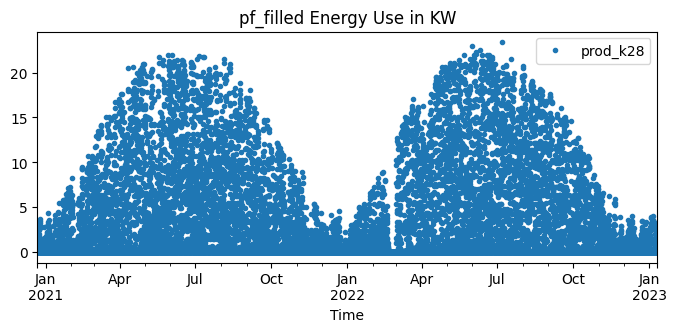

In [88]:
df.plot(style='.',
        figsize=(8, 3),
        color=color_pal[0],
        title=f'{dataset_name} Energy Use in KW')
plt.savefig(f"figure1-{dataset_name}.png")
plt.show()

In [89]:
# Split data to Train and Test

date = '09-01-2022'
train = df.loc[df.index < date]
test = df.loc[df.index >= date]


In [90]:
test

,prod_k28
Time,
2022-09-01 00:00:00,0.0
2022-09-01 01:00:00,0.0
2022-09-01 02:00:00,0.0
2022-09-01 03:00:00,0.0
2022-09-01 04:00:00,0.0
...,...
2023-01-10 16:00:00,0.3
2023-01-10 17:00:00,0.0
2023-01-10 18:00:00,0.0


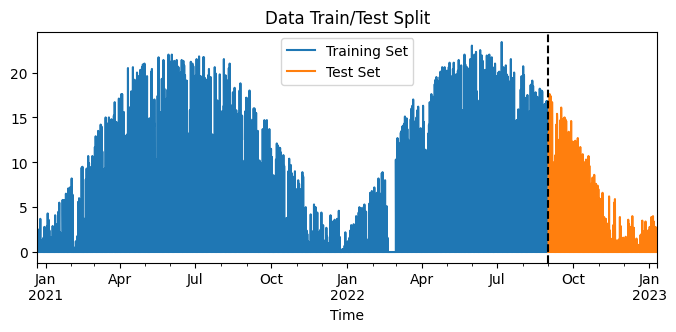

In [91]:

fig, ax = plt.subplots(figsize=(8, 3),)
train.plot(ax=ax, label='Training Set', title='Data Train/Test Split')
test.plot(ax=ax, label='Test Set')
ax.axvline(date, color='black', ls='--')
ax.legend(['Training Set', 'Test Set'])
plt.savefig(f"figure2-{dataset_name}.png")
plt.show()

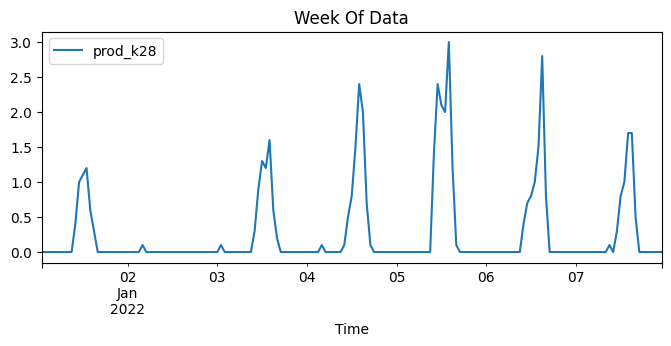

In [92]:
start_of_week = '01-01-2022'
end_of_week = '01-08-2022'

df.loc[(df.index > start_of_week) & (df.index < end_of_week)] \
    .plot(figsize=(8, 3), title='Week Of Data')

plt.savefig(f"figure3-{dataset_name}.png")
plt.show()

In [93]:
df.index

DatetimeIndex(['2020-12-22 00:00:00', '2020-12-22 01:00:00',
               '2020-12-22 02:00:00', '2020-12-22 03:00:00',
               '2020-12-22 04:00:00', '2020-12-22 05:00:00',
               '2020-12-22 06:00:00', '2020-12-22 07:00:00',
               '2020-12-22 08:00:00', '2020-12-22 09:00:00',
               ...
               '2023-01-10 11:00:00', '2023-01-10 12:00:00',
               '2023-01-10 13:00:00', '2023-01-10 14:00:00',
               '2023-01-10 15:00:00', '2023-01-10 16:00:00',
               '2023-01-10 17:00:00', '2023-01-10 18:00:00',
               '2023-01-10 19:00:00', '2023-01-10 20:00:00'],
              dtype='datetime64[ns]', name='Time', length=17997, freq=None)

In [94]:
df.index.dayofweek
print(df)

                     prod_k28
Time                         
2020-12-22 00:00:00       0.0
2020-12-22 01:00:00       0.0
2020-12-22 02:00:00       0.0
2020-12-22 03:00:00       0.0
2020-12-22 04:00:00       0.0
...                       ...
2023-01-10 16:00:00       0.3
2023-01-10 17:00:00       0.0
2023-01-10 18:00:00       0.0
2023-01-10 19:00:00       0.0
2023-01-10 20:00:00       0.0

[17997 rows x 1 columns]


In [95]:
# df.columns

In [96]:
df

,prod_k28
Time,
2020-12-22 00:00:00,0.0
2020-12-22 01:00:00,0.0
2020-12-22 02:00:00,0.0
2020-12-22 03:00:00,0.0
2020-12-22 04:00:00,0.0
...,...
2023-01-10 16:00:00,0.3
2023-01-10 17:00:00,0.0
2023-01-10 18:00:00,0.0


In [97]:
def create_features(df):
    """
    Create time series features based on time series index.
    """
    df = df.copy()
    df['hour'] = df.index.hour
    df['dayofweek'] = df.index.dayofweek
    df['quarter'] = df.index.quarter
    df['month'] = df.index.month
    df['year'] = df.index.year
    df['dayofyear'] = df.index.dayofyear
    df['dayofmonth'] = df.index.day
    df['weekofyear'] = df.index.isocalendar().week
    return df


df = create_features(df)

In [98]:
df

,prod_k28,hour,dayofweek,quarter,month,year,dayofyear,dayofmonth,weekofyear
Time,,,,,,,,,
2020-12-22 00:00:00,0.0,0,1,4,12,2020,357,22,52
2020-12-22 01:00:00,0.0,1,1,4,12,2020,357,22,52
2020-12-22 02:00:00,0.0,2,1,4,12,2020,357,22,52
2020-12-22 03:00:00,0.0,3,1,4,12,2020,357,22,52
2020-12-22 04:00:00,0.0,4,1,4,12,2020,357,22,52
...,...,...,...,...,...,...,...,...,...
2023-01-10 16:00:00,0.3,16,1,1,1,2023,10,10,2
2023-01-10 17:00:00,0.0,17,1,1,1,2023,10,10,2
2023-01-10 18:00:00,0.0,18,1,1,1,2023,10,10,2


In [99]:
dataset_name

'pf_filled'

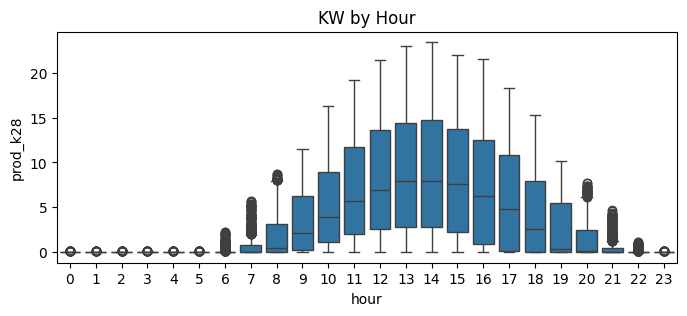

In [100]:
fig, ax = plt.subplots(figsize=(8, 3),)
# sns.boxplot(data=df, x='hour', y='PJME_MW')
y_label = selected_column
sns.boxplot(data=df, x='hour', y=y_label)
ax.set_title('KW by Hour')
plt.savefig(f"figure4-{dataset_name}.png")
plt.show()

<ipython-input-101-152b059221af>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='month', y=y_label, palette='Blues')


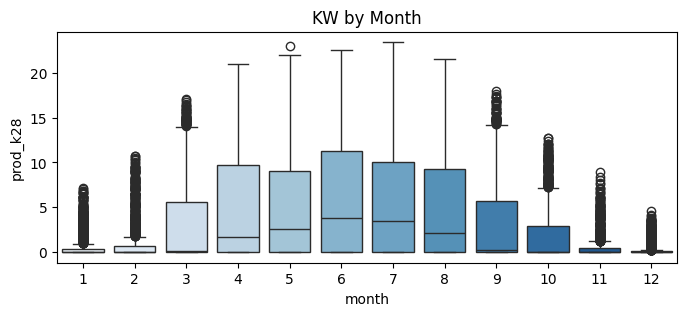

In [101]:
fig, ax = plt.subplots(figsize=(8, 3),)
# sns.boxplot(data=df, x='month', y='PJME_MW', palette='Blues')
sns.boxplot(data=df, x='month', y=y_label, palette='Blues')
ax.set_title('KW by Month')
plt.savefig(f"figure5-{dataset_name}.png")
plt.show()

In [102]:
train = create_features(train)
test = create_features(test)

FEATURES = ['dayofyear', 'hour', 'dayofweek', 'quarter', 'month', 'year']
# TARGET = 'PJME_MW'
TARGET = y_label

X_train = train[FEATURES]
y_train = train[TARGET]

X_test = test[FEATURES]
y_test = test[TARGET]

# XGboost

In [103]:
import xgboost as xgb

reg = xgb.XGBRegressor(base_score=0.5, booster='gbtree',
                       n_estimators=1000,
                       early_stopping_rounds=50,
                       objective='reg:linear',
                       max_depth=3,
                       learning_rate=0.01)
reg.fit(X_train, y_train,
        eval_set=[(X_train, y_train), (X_test, y_test)],
        verbose=100)
y_pred = reg.predict(X_test)


[0]	validation_0-rmse:6.05599	validation_1-rmse:3.11403


/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning: [11:20:16] WARNING: /workspace/src/objective/regression_obj.cu:227: reg:linear is now deprecated in favor of reg:squarederror.
  warnings.warn(smsg, UserWarning)


[100]	validation_0-rmse:3.77652	validation_1-rmse:2.08502
[200]	validation_0-rmse:2.96321	validation_1-rmse:1.78657
[300]	validation_0-rmse:2.64533	validation_1-rmse:1.68299
[400]	validation_0-rmse:2.50359	validation_1-rmse:1.64496
[413]	validation_0-rmse:2.49121	validation_1-rmse:1.64718


RMSE Score on Test set: 1.63
mae Score on Test set: 1.07
r2 Score on Test set: 0.70
mbe Score on Test set: -0.20
medae Score on Test set: 0.49
cod Score on Test set: 0.70
explained_variance Score on Test set: 0.71
rae Score on Test set: 0.53


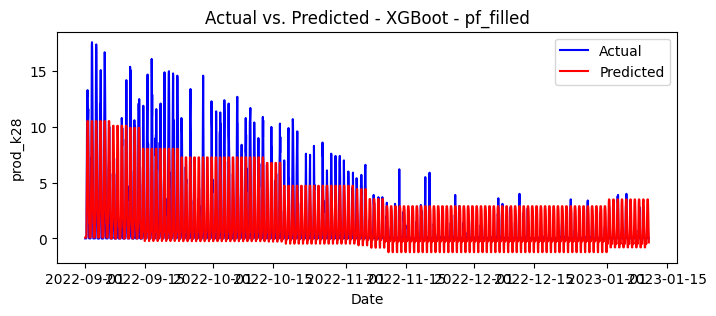

In [104]:
plot_act_vs_pred(y_test, y_pred,y_label, 'XGBoot', dataset_name)

# DNN

In [105]:
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

# Build a deep neural network model using TensorFlow and Keras
model = tf.keras.Sequential([
    tf.keras.layers.Dense(10, activation='relu', input_shape=(6,)),
    tf.keras.layers.Dense(10, activation='relu'),
    tf.keras.layers.Dense(1)
])

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# Train the model
history = model.fit(X_train, y_train, epochs=100, validation_data=(X_test, y_test), verbose=1)

# Make predictions on the test set
y_pred = model.predict(X_test)



Epoch 1/100


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


464/464 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 691.9390 - val_loss: 29.2013
Epoch 2/100
464/464 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 39.3777 - val_loss: 26.6767
Epoch 3/100
464/464 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 32.5985 - val_loss: 18.0017
Epoch 4/100
464/464 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 29.5814 - val_loss: 10.4348
Epoch 5/100
464/464 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 30.7911 - val_loss: 11.8204
Epoch 6/100
464/464 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 32.1392 - val_loss: 9.6911
Epoch 7/100
464/464 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 30.7442 - val_loss: 40.2005
Epoch 8/100
464/464 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 29.9540 - val_loss: 11.7898
Epoch 9/100
464/464 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 32.7870 - val_loss: 11.5780
Epoch 10/100
464/464 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 30.6646 - val_loss: 9.4891
Epoch 11/100
464/464 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 30.4411 - val_loss: 12.6962
Epoch 12/100
464/464 ━━━━━━━━━━━

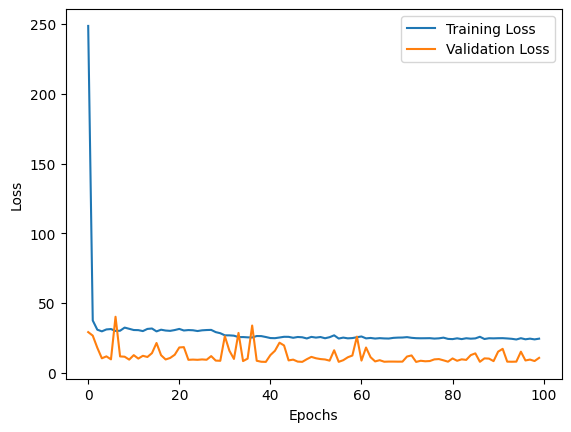

In [106]:

# Visualize the training loss and validation loss over epochs
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

RMSE Score on Test set: 3.28
mae Score on Test set: 2.64
r2 Score on Test set: -0.19
mbe Score on Test set: -1.66
medae Score on Test set: 2.37
cod Score on Test set: -0.19
explained_variance Score on Test set: 0.11
rae Score on Test set: 1.31


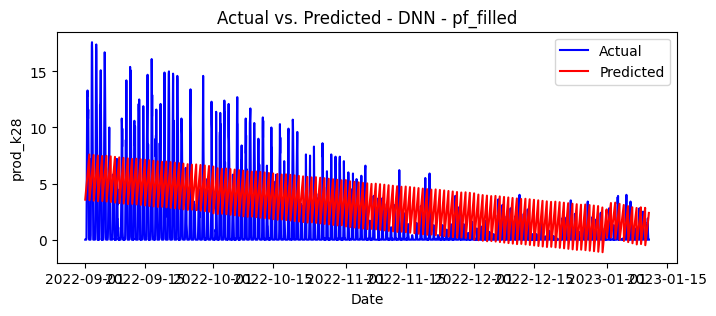

In [107]:
plot_act_vs_pred(y_test, y_pred,y_label, 'DNN', dataset_name)

# DNN Parameter Tuning using GA:

In [108]:
!pip install deap

In [109]:
!pip install pyswarm

In [110]:
no_optimizatin_epochs = 10
evaluation_epochs = 10
ga_population_size = 10
ga_ngen = 10
pso_swarm_size = 10
pso_maxiter = 10
best_model_pso_epochs = 100

In [111]:
import random
import numpy as np
from deap import base, creator, tools, algorithms
import tensorflow as tf
from tensorflow import keras

# Define the fitness function
nfe = 0
def evaluate(individual):
    global nfe
    nfe += 1
    print(nfe)
    individual[0] = int(individual[0])
    individual[1] = int(individual[1])
    print('first layer: ', individual[0])
    print('second layer: ', individual[1])
    # Define the architecture of the neural network based on the individual's genes
    model = keras.Sequential()
    # print('**** Shape: ', X_train.shape)
    model.add(keras.layers.Dense(int(individual[0]), activation='relu', input_shape=(X_train.shape[1],)))
    model.add(keras.layers.Dense(int(individual[1]), activation='relu'))
    model.add(keras.layers.Dense(1))

    # Compile the model
    model.compile(optimizer='adam', loss='mean_squared_error')

    # Train and evaluate the model
    history = model.fit(X_train, y_train, epochs=evaluation_epochs, validation_data=(X_test, y_test), verbose=0)
    loss = history.history['val_loss'][-1]

    return (loss,)

# Create a fitness function maximizing minimization
creator.create("FitnessMin", base.Fitness, weights=(-1.0,))
creator.create("Individual", list, fitness=creator.FitnessMin)

# Create a toolbox for GA
toolbox_ga = base.Toolbox()
toolbox_ga.register("attr_int", random.randint, 16, 128)  # For the number of neurons in layers
toolbox_ga.register("individual", tools.initRepeat, creator.Individual, toolbox_ga.attr_int, n=2)
toolbox_ga.register("population", tools.initRepeat, list, toolbox_ga.individual)

toolbox_ga.register("evaluate", evaluate)
toolbox_ga.register("mate", tools.cxTwoPoint)
toolbox_ga.register("mutate", tools.mutUniformInt, low=16, up=128, indpb=0.2)
toolbox_ga.register("select", tools.selTournament, tournsize=3)

# Define your X_train and Y_train datasets here

# Create the initial GA population
ga_population = toolbox_ga.population(n=ga_population_size)

# Run the genetic algorithm
algorithms.eaSimple(ga_population, toolbox_ga, cxpb=0.7, mutpb=0.2, ngen=ga_ngen, verbose=True)

# Get the best individual from the GA population
best_individual_ga = tools.selBest(ga_population, k=1)[0]

# Create a PSO population with the best GA individual as the initial particle
from pyswarm import pso

def pso_optimization(individual):
    loss = evaluate(individual)[0]
    return loss

# Convert the GA individual to a PSO-friendly format (list of integers)
best_individual_pso = [int(best_individual_ga[0]), int(best_individual_ga[1])]

# Define the bounds for PSO
lb = [16, 16]
ub = [128, 128]

# Run PSO with the best GA individual as the initial particle
x_opt, f_opt = pso(pso_optimization, lb, ub, swarmsize=pso_swarm_size, maxiter=pso_maxiter)

# Print the results
print("Best architecture found by PSO:", x_opt)
print("Best architecture found by PSO (rounded):", [int(x_opt[0]), int(x_opt[1])])

# Train and evaluate the best model with the architecture found by PSO
best_model_pso = keras.Sequential()
best_model_pso.add(keras.layers.Dense(int(x_opt[0]), activation='relu', input_shape=(X_train.shape[1],)))
best_model_pso.add(keras.layers.Dense(int(x_opt[1]), activation='relu'))
best_model_pso.add(keras.layers.Dense(1))
best_model_pso.compile(optimizer='adam', loss='mean_squared_error')

history2 = best_model_pso.fit(X_train, y_train, epochs=best_model_pso_epochs, verbose=1, validation_data=(X_test, y_test))
test_loss = best_model_pso.evaluate(X_test, y_test)
print(f"Test Loss: {test_loss}")


/usr/local/lib/python3.10/dist-packages/deap/creator.py:185: RuntimeWarning: A class named 'FitnessMin' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.
  warnings.warn("A class named '{0}' has already been created and it "
/usr/local/lib/python3.10/dist-packages/deap/creator.py:185: RuntimeWarning: A class named 'Individual' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.
  warnings.warn("A class named '{0}' has already been created and it "
/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1
first layer:  63
second layer:  110
2
first layer:  41
second layer:  50


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3
first layer:  124
second layer:  55


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


...

204
first layer:  106.0
second layer:  89.0


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Stopping search: maximum iterations reached --> 10
Best architecture found by PSO: [108.  89.]
Best architecture found by PSO (rounded): [108, 89]
Epoch 1/100


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


464/464 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 708.5823 - val_loss: 7.9808
Epoch 2/100
464/464 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 26.8257 - val_loss: 10.4454
Epoch 3/100
464/464 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 25.4885 - val_loss: 45.4080
Epoch 4/100
464/464 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 30.6990 - val_loss: 7.9312
Epoch 5/100
464/464 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 28.6152 - val_loss: 9.7023
Epoch 6/100
464/464 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 26.3642 - val_loss: 13.4057
Epoch 7/100
464/464 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 34.9594 - val_loss: 8.7902
Epoch 8/100
464/464 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 30.6121 - val_loss: 9.8892
Epoch 9/100
464/464 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 28.2220 - val_loss: 10.3166
Epoch 10/100
464/464 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 27.4274 - val_loss: 9.4275
Epoch 11/100
464/464 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 27.8701 - val_loss: 8.9653
Epoch 12/100
464/464 ━━━━━━━━━━━━━━━━

In [112]:
# Make predictions
y_pred = best_model_pso.predict(X_test)

99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


RMSE Score on Test set: 1.47
mae Score on Test set: 0.71
r2 Score on Test set: 0.76
mbe Score on Test set: 0.19
medae Score on Test set: 0.03
cod Score on Test set: 0.76
explained_variance Score on Test set: 0.76
rae Score on Test set: 0.35


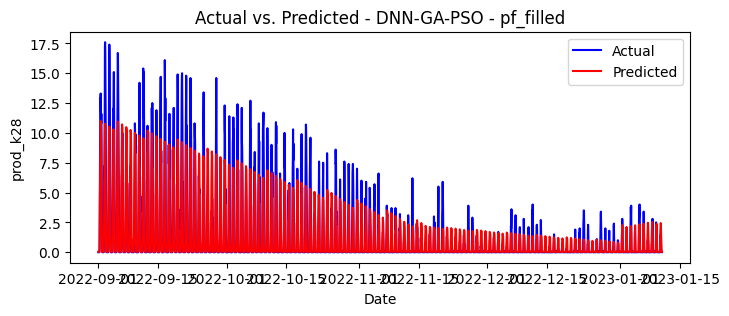

In [113]:
plot_act_vs_pred(y_test, y_pred,y_label, 'DNN-GA-PSO', dataset_name)